In [ ]:
!pip -q install -U bitsandbytes>=0.46.1



In [ ]:
import os, json, time, gc, platform
from datetime import datetime
import torch

RUN_NAME = f"gemma2-2b-xsum-lora-vs-qlora-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
OUTPUT_DIR = f"/content/{RUN_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gpu_info():
    info = {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "platform": platform.platform(),
        "python": platform.python_version(),
    }
    if torch.cuda.is_available():
        info.update({
            "gpu_name": torch.cuda.get_device_name(0),
            "vram_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
            "bf16_supported": torch.cuda.is_bf16_supported(),
        })
    return info

info = gpu_info()
print(info)

with open(os.path.join(OUTPUT_DIR, "hardware_env.json"), "w") as f:
    json.dump(info, f, indent=2)

def reset_cuda_stats():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def peak_mem_gb():
    if torch.cuda.is_available():
        return round(torch.cuda.max_memory_allocated() / 1024**3, 3)
    return None

print("Run folder:", OUTPUT_DIR)
if torch.cuda.is_available():
    print("Free/Total GB:", [round(x/1024**3,2) for x in torch.cuda.mem_get_info()])



{'torch_version': '2.10.0+cu128', 'cuda_available': True, 'platform': 'Linux-6.6.113+-x86_64-with-glibc2.35', 'python': '3.12.12', 'gpu_name': 'Tesla T4', 'vram_gb': 14.56, 'bf16_supported': True}
Run folder: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626
Free/Total GB: [14.46, 14.56]


#**Load Xsum Subset**

In [ ]:
from datasets import load_dataset

ds = load_dataset("xsum")

# Start modest for speed; scale later if you have time
TRAIN_N = 2000
VAL_N   = 300
TEST_N  = 300

train_ds = ds["train"].shuffle(seed=42).select(range(TRAIN_N))
val_ds   = ds["validation"].shuffle(seed=42).select(range(VAL_N))
test_ds  = ds["test"].shuffle(seed=42).select(range(TEST_N))

print("Sizes:", len(train_ds), len(val_ds), len(test_ds))
print(train_ds[0].keys())


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

Sizes: 2000 300 300
dict_keys(['document', 'summary', 'id'])


#**Prompt + Preprocessing**

In [ ]:
def build_prompt(document: str) -> str:
    return (
        "You are a helpful assistant.\n"
        "Summarize the following news article in one concise paragraph.\n\n"
        "ARTICLE:\n"
        f"{document}\n\n"
        "SUMMARY:\n"
    )

def format_sft_example(example):
    prompt = build_prompt(example["document"])
    target = example["summary"].strip()
    return {"text": prompt + target}


#**Metrix (Rouge) +Generation Helper**

In [ ]:
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=35e73948a94b030d414813cd2f3cbb69557f5083c488e7af59ac1c732411c479
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
import evaluate
rouge = evaluate.load("rouge")

def compute_rouge(preds, refs):
    # evaluate library returns rouge1/rouge2/rougeL/rougeLsum (F1 by default)
    return rouge.compute(predictions=preds, references=refs, use_stemmer=True)

def safe_decode(tokenizer, ids):
    return tokenizer.decode(ids, skip_special_tokens=True)

def extract_after_summary(text: str) -> str:
    if "SUMMARY:" in text:
        return text.split("SUMMARY:", 1)[-1].strip()
    return text.strip()

#**Utility: trainable params summary + logging**

In [ ]:
def param_summary(model):
    total = 0
    trainable = 0
    for p in model.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    pct = 100.0 * trainable / total if total else 0.0
    return {"total_params": total, "trainable_params": trainable, "trainable_pct": pct}

def save_json(name, obj):
    path = os.path.join(OUTPUT_DIR, name)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print("Saved:", path)

def cleanup(model=None, tokenizer=None):
    try:
        if model is not None:
            del model
        if tokenizer is not None:
            del tokenizer
    except:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


#**Load model/tokenizer (function supports QLoRA or LoRA)**

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "google/gemma-2-2b-it"

def load_model(quant_mode: str):
    """
    quant_mode: "qlora4bit" or "lora16bit"
    """
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    if quant_mode == "qlora4bit":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            quantization_config=bnb_config,
            device_map="auto",
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
            low_cpu_mem_usage=True, # Added for memory efficiency
        )
    elif quant_mode == "lora16bit":
        # No 4bit quantization; will be heavier on VRAM
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            device_map="auto",
            torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float16,
            low_cpu_mem_usage=True, # Added for memory efficiency
        )
    else:
        raise ValueError("quant_mode must be 'qlora4bit' or 'lora16bit'")

    model.config.use_cache = False
    return model, tokenizer

print("Ready.")

Ready.


#**Generation + EVALUATION loop**

In [ ]:
@torch.no_grad()
def generate_one(model, tokenizer, prompt, max_new_tokens=60):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=768).to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        num_beams=1,  # greedy decode (FAST)
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    text = safe_decode(tokenizer, out[0])
    return extract_after_summary(text)

def eval_on_test(model, tokenizer, dataset, limit=50, tag=""):
    reset_cuda_stats()
    preds, refs = [], []
    for i in range(min(limit, len(dataset))):
        doc = dataset[i]["document"]
        ref = dataset[i]["summary"]
        pred = generate_one(model, tokenizer, build_prompt(doc))
        preds.append(pred)
        refs.append(ref)
        if (i+1) % 10 == 0:
            print(f"[{tag}] {i+1}/{min(limit, len(dataset))} done")
    scores = compute_rouge(preds, refs)
    mem = peak_mem_gb()
    return scores, mem, preds, refs


#**Baseline (No Fine Tuning) Rouge**

In [ ]:
model_base, tok_base = load_model("qlora4bit")
model_base.eval()

BASELINE_LIMIT = 30  # faster for iteration
baseline_scores, baseline_mem, baseline_preds, baseline_refs = eval_on_test(
    model_base, tok_base, test_ds, limit=BASELINE_LIMIT, tag="BASELINE"
)

print("Baseline ROUGE:", baseline_scores)
print("Baseline peak VRAM GB:", baseline_mem)

save_json("baseline_rouge.json", baseline_scores)
save_json("baseline_meta.json", {"limit": BASELINE_LIMIT, "peak_vram_gb": baseline_mem, "mode":"4bit_inference"})


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

[BASELINE] 10/30 done
[BASELINE] 20/30 done
[BASELINE] 30/30 done
Baseline ROUGE: {'rouge1': np.float64(0.22903744676770665), 'rouge2': np.float64(0.06193734207157507), 'rougeL': np.float64(0.1646111660913557), 'rougeLsum': np.float64(0.16285469328501567)}
Baseline peak VRAM GB: 2.268
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/baseline_rouge.json
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/baseline_meta.json


#Prepare SFT datasets for training

In [ ]:
train_sft = train_ds.map(format_sft_example, remove_columns=train_ds.column_names)
val_sft   = val_ds.map(format_sft_example, remove_columns=val_ds.column_names)

print(train_sft[0]["text"][:400])


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

You are a helpful assistant.
Summarize the following news article in one concise paragraph.

ARTICLE:
In Wales, councils are responsible for funding and overseeing schools.
But in England, Mr Osborne's plan will mean local authorities will cease to have a role in providing education.
Academies are directly funded by central government and head teachers have more freedom over admissions and to chan


#**Train QLoRA (PEFT) with TRL SFTTrainer**

In [ ]:
!pip install trl


In [ ]:
import os, time, gc
import torch
import trl
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from transformers import TrainingArguments

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# Clean up baseline model
cleanup(model_base, tok_base)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load 4-bit model for QLoRA
model_q, tok_q = load_model("qlora4bit")
model_q = prepare_model_for_kbit_training(model_q)

# Define max sequence length for tokenization
MAX_SEQ_LENGTH = 256

def tokenize_function(examples):
    # This assumes format_sft_example returns {'text': ...}
    # and the prompt is built as before.
    # The format_sft_example already prepares 'text' field.
    return tok_q(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding='max_length' # Pad to max_length for consistent input shapes
    )

# First, format the datasets to have the 'text' field
train_sft = train_ds.map(format_sft_example, remove_columns=train_ds.column_names)
val_sft   = val_ds.map(format_sft_example, remove_columns=val_ds.column_names)

# Now, tokenize the formatted datasets with the defined MAX_SEQ_LENGTH
train_tokenized_ds = train_sft.map(tokenize_function, batched=True, remove_columns=['text'])
val_tokenized_ds   = val_sft.map(tokenize_function, batched=True, remove_columns=['text'])

# Smaller LoRA = less VRAM
lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
model_q = get_peft_model(model_q, lora_cfg)

q_params = param_summary(model_q)
print("QLoRA param summary:", q_params)
save_json("qlora_param_summary.json", q_params)

reset_cuda_stats()
t0 = time.time()

# Calculate warmup steps based on ratio (using dataset size for calculation)
GRADIENT_ACCUMULATION_STEPS = 8
num_training_steps = int(len(train_tokenized_ds) / (1 * GRADIENT_ACCUMULATION_STEPS) * 1) # (dataset_size / (per_device_train_batch_size * gradient_accumulation_steps)) * num_train_epochs
warmup_steps = int(num_training_steps * 0.03)

args_q = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "qlora_ckpt"),
    per_device_train_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=10,
    eval_strategy="no", # Disable evaluation during training to save VRAM
    # eval_steps=100, # Removed as eval_strategy is "no"
    save_steps=100,
    save_total_limit=2,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    report_to="none",
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps, # Changed from warmup_ratio
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant':False}, # Explicitly set use_reentrant
)

trainer_q = SFTTrainer(
    model=model_q,
    # tokenizer=tok_q, # Removed as dataset is pre-tokenized
    train_dataset=train_tokenized_ds,
    eval_dataset=val_tokenized_ds,
    # dataset_text_field="text", # Removed as dataset is pre-tokenized
    # max_seq_length=256, # Removed as dataset is pre-tokenized
    # packing=True,           # Removed as it's not supported in this trl version
    args=args_q,
)

trainer_q.train()

train_time_q = time.time() - t0
peak_train_mem_q = peak_mem_gb()

qlora_adapter_dir = os.path.join(OUTPUT_DIR, "qlora_adapter")
trainer_q.model.save_pretrained(qlora_adapter_dir)
tok_q.save_pretrained(qlora_adapter_dir)

training_args_dict = args_q.to_dict()
# Convert any sets within training_args_dict to lists for JSON serialization
for key, value in training_args_dict.items():
    if isinstance(value, set):
        training_args_dict[key] = list(value)

lora_config_dict = lora_cfg.to_dict()
# Convert any sets within lora_config_dict to lists (though less likely for LoraConfig)
for key, value in lora_config_dict.items():
    if isinstance(value, set):
        lora_config_dict[key] = list(value)

save_json("qlora_train_meta.json", {
    "train_seconds": train_time_q,
    "peak_train_vram_gb": peak_train_mem_q,
    "training_args": training_args_dict,
    "lora_config": lora_config_dict
})

print("QLoRA training done. Time(s):", round(train_time_q, 1), "Peak VRAM(GB):", peak_train_mem_q)


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

QLoRA param summary: {'total_params': 1612587264, 'trainable_params': 10383360, 'trainable_pct': 0.6438944565545074}
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qlora_param_summary.json


Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss
10,3.781175
20,2.191561
30,2.015986
40,2.022239
50,1.825006
60,1.930379
70,1.868641
80,1.889012
90,1.875491
100,1.854531


Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qlora_train_meta.json
QLoRA training done. Time(s): 4799.2 Peak VRAM(GB): 7.497


#Evaluate QLoRA ROUGE

In [ ]:
trainer_q.model.eval()

qlora_scores, qlora_eval_mem, qlora_preds, qlora_refs = eval_on_test(
    trainer_q.model, tok_q, test_ds, limit=BASELINE_LIMIT, tag="QLORA"
)

print("QLoRA ROUGE:", qlora_scores)
print("QLoRA eval peak VRAM GB:", qlora_eval_mem)

save_json("qlora_rouge.json", qlora_scores)
save_json("qlora_eval_meta.json", {"limit": BASELINE_LIMIT, "peak_vram_gb": qlora_eval_mem, "mode":"QLoRA"})

[QLORA] 10/30 done
[QLORA] 20/30 done
[QLORA] 30/30 done
QLoRA ROUGE: {'rouge1': np.float64(0.24177993321151642), 'rouge2': np.float64(0.061027243451989), 'rougeL': np.float64(0.17256191752442068), 'rougeLsum': np.float64(0.1915418859180375)}
QLoRA eval peak VRAM GB: 5.635
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qlora_rouge.json
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qlora_eval_meta.json


## Qualitative examples (Baseline vs QLoRA only)

In [ ]:
# CELL 14 — Qualitative examples (Baseline vs QLoRA only)
import pandas as pd, random, os

rows = []
sample_k = 10
limit_used = min(BASELINE_LIMIT, len(baseline_preds), len(qlora_preds))
indices = random.sample(range(limit_used), min(sample_k, limit_used))

for i in indices:
    rows.append({
        "doc_snippet": test_ds[i]["document"][:350].replace("\n"," "),
        "reference": baseline_refs[i],
        "baseline": baseline_preds[i],
        "qlora": qlora_preds[i],
    })

df = pd.DataFrame(rows)
csv_path = os.path.join(OUTPUT_DIR, "qualitative_examples.csv")
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)
df


Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qualitative_examples.csv


,doc_snippet,reference,baseline,qlora
0,Northern Ireland's world number three is due t...,Rory McIlroy hopes to play in the WGC-HSBC Cha...,"Rory McIlroy, the world number three golfer fr...",Rory McIlroy has withdrawn from this week's DP...
1,Michelle O'Neill hosted a departmental breakfa...,The agriculture minister is to return to China...,"Michelle O'Neill, Agriculture Minister for Nor...",The first Minister has been speaking about how...
2,Sarah Johnson was one of 21 women heading to L...,A woman who was seriously hurt in a fatal hen ...,After being involved in a serious accident tha...,A woman who survived a fatal road crash that k...
3,"The children, who had previously lived in area...",The UN says it has negotiated the release of 8...,**Children held in Nigerian military barracks ...,At least 350 children have been rescued from a...
4,"Aiton, 30, had scans to diagnose the injury on...",Catalans Dragons will be without hooker Paul A...,**[Name] Aiton has been diagnosed with a [inju...,Dragons prop Ashton Aiton has been ruled out f...
5,"John Morley, 29, of Deanstown, Finglas West, i...",A Dublin man accused of stabbing his friend in...,John Morley (29) has been arrested and charged...,A man has appeared in court charged with stabb...
6,"Liberty, headed by Sanjeev Gupta, was first to...",Liberty House plans to submit a formal bid on ...,"Liberty House, led by Sanjeev Gupta, is prepar...",Indian tycoon Sanjeev Gupta's company Liberty ...
7,"Allsop, 25, made his Premier League debut in N...",Blackpool have signed Bournemouth goalkeeper R...,Blackpool Football Club has signed two new pla...,Blackpool have completed the signing of midfie...
8,"President Raul Castro said ""attempts to destro...",The president of Cuba has spoken publicly for ...,Cuban President Raul Castro addressed the nati...,Cuban President Raul Castro says he rejects at...
9,"Surman, 28, arrives back at Dean Court having ...",Bournemouth have signed Norwich midfielder And...,"Southampton's midfielder, Surman, has returned...",Southampton midfielder Matt Targett has signed...


In [ ]:
# CELL 15 — Results table (Baseline vs QLoRA only)
import pandas as pd, os, json

def to_row(name, scores, train_meta=None, params=None):
    row = {"model": name}
    row.update({
        "rouge1": scores.get("rouge1"),
        "rouge2": scores.get("rouge2"),
        "rougeL": scores.get("rougeL"),
        "rougeLsum": scores.get("rougeLsum"),
    })
    if train_meta:
        row.update({
            "train_seconds": train_meta.get("train_seconds"),
            "peak_train_vram_gb": train_meta.get("peak_train_vram_gb"),
        })
    if params:
        row.update({
            "trainable_pct": params.get("trainable_pct"),
            "trainable_params": params.get("trainable_params"),
            "total_params": params.get("total_params"),
        })
    return row

# Load QLoRA meta if you saved them
qlora_train_meta_path = os.path.join(OUTPUT_DIR, "qlora_train_meta.json")
qlora_param_path = os.path.join(OUTPUT_DIR, "qlora_param_summary.json")

qlora_train_meta = json.load(open(qlora_train_meta_path)) if os.path.exists(qlora_train_meta_path) else None
qlora_params = json.load(open(qlora_param_path)) if os.path.exists(qlora_param_path) else None

results = [
    to_row("Baseline (4bit inference)", baseline_scores),
    to_row("QLoRA (4bit + LoRA adapters)", qlora_scores, train_meta=qlora_train_meta, params=qlora_params),
]

df_results = pd.DataFrame(results)
table_path = os.path.join(OUTPUT_DIR, "results_table.csv")
df_results.to_csv(table_path, index=False)
print("Saved:", table_path)
df_results


Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/results_table.csv


,model,rouge1,rouge2,rougeL,rougeLsum,train_seconds,peak_train_vram_gb,trainable_pct,trainable_params,total_params
0,Baseline (4bit inference),0.229037,0.061937,0.164611,0.162855,NaN,NaN,NaN,NaN,NaN
1,QLoRA (4bit + LoRA adapters),0.241780,0.061027,0.172562,0.191542,4799.232465,7.497,0.643894,10383360.0,1.612587e+09


In [ ]:
zip_name = f"{RUN_NAME}.zip"
!zip -r "{zip_name}" "{OUTPUT_DIR}" > /content/zip_log.txt
print("Zipped to:", f"/content/{zip_name}")


Zipped to: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626.zip


In [ ]:
!pip -q install -U bert-score
import evaluate

bertscore = evaluate.load("bertscore")

def compute_bertscore(preds, refs):
    out = bertscore.compute(predictions=preds, references=refs, lang="en")
    return {
        "precision": sum(out["precision"]) / len(out["precision"]),
        "recall": sum(out["recall"]) / len(out["recall"]),
        "f1": sum(out["f1"]) / len(out["f1"]),
    }

baseline_bs = compute_bertscore(baseline_preds, baseline_refs)
qlora_bs    = compute_bertscore(qlora_preds, qlora_refs)

save_json("baseline_bertscore.json", baseline_bs)
save_json("qlora_bertscore.json", qlora_bs)

print("Baseline:", baseline_bs)
print("QLoRA:", qlora_bs)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.5 MB/s eta 0:00:00


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/baseline_bertscore.json
Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/qlora_bertscore.json
Baseline: {'precision': 0.8546531875928243, 'recall': 0.892307045062383, 'f1': 0.872902641693751}
QLoRA: {'precision': 0.859456213315328, 'recall': 0.896234021584193, 'f1': 0.8772716422875723}


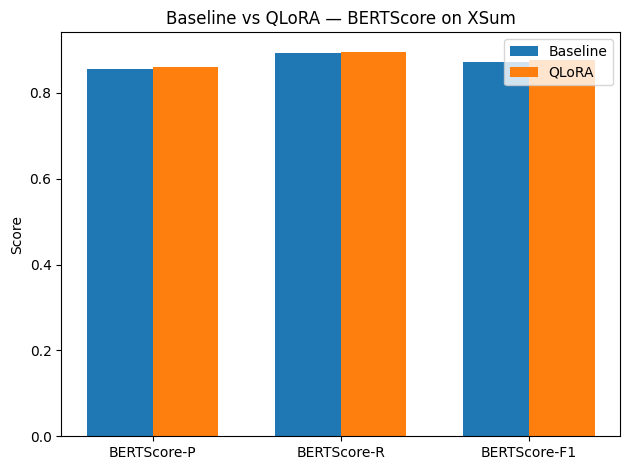

Saved: /content/gemma2-2b-xsum-lora-vs-qlora-20260224-165626/bertscore_comparison.png


In [ ]:
import os, json
import matplotlib.pyplot as plt

# Load saved BERTScore results
baseline_bs = json.load(open(os.path.join(OUTPUT_DIR, "baseline_bertscore.json")))
qlora_bs    = json.load(open(os.path.join(OUTPUT_DIR, "qlora_bertscore.json")))

metrics = ["precision", "recall", "f1"]
baseline_vals = [baseline_bs[m] for m in metrics]
qlora_vals    = [qlora_bs[m] for m in metrics]

x = range(len(metrics))
w = 0.35

plt.figure()
plt.bar([i - w/2 for i in x], baseline_vals, width=w, label="Baseline")
plt.bar([i + w/2 for i in x], qlora_vals, width=w, label="QLoRA")
plt.xticks(list(x), ["BERTScore-P", "BERTScore-R", "BERTScore-F1"])
plt.ylabel("Score")
plt.title("Baseline vs QLoRA — BERTScore on XSum")
plt.legend()
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, "bertscore_comparison.png")
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)
